# StegTransX-CR on Google Colab Pro+

Multi-format compression-resilient deep image steganography: hide a full-resolution secret image inside a cover image so that it survives JPEG, WebP, HEIF and AVIF compression, including cascading recompression chains such as `JPEG -> WebP -> JPEG`.

This notebook implements the technical specification for the paper *StegTransX-CR: Multi-Format Compression-Resilient Deep Steganography via Unified Differentiable Codec Simulation and Frequency-Adaptive Embedding*.

## Protocol deviations from the paper

These are deliberate. Mention them in the methods section of the report.

| Topic | Paper | Here |
|---|---|---|
| Reveal input | Algorithm 1 passes the codec `k` to the reveal network | image only, matching Algorithm 4 and real deployment |
| Hiding and reveal losses | section 3.6.1 names Charbonnier, equations (14)-(15) omit it | Laplacian pyramid + Charbonnier + restriction |
| Epochs | 8,000 per experiment | at most 500, early stopping on validation secret PSNR with patience 9 |
| Test compression | differentiable simulator only | simulator **and** real `.jpg` / `.webp` / `.heic` / `.avif` files |
| Weight of the hiding loss | fixed at 1.0 | held near 0, then ramped to 1.0 (see section 6) |

## Running order

1. Environment and dependencies
2. Data
3. Models and codec simulators
4. Optional: calibrate the simulators against real encoders
5. Learning sanity check - **run this before committing to the long experiments**
6. Experiments A, B and C
7. Evaluation, figures and LaTeX tables

Set the runtime to a GPU: `Runtime -> Change runtime type -> A100` (or L4).

## 1. Environment, dependencies and paths

`pillow-heif` and `pillow-avif-plugin` are what make the **real** HEIF and AVIF
measurements possible. Without them those two codecs are still simulated and
trained on, but the real-file columns of the results tables are reported as
unavailable rather than guessed.

In [3]:
!pip -q install pillow-heif pillow-avif-plugin
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
NVIDIA A100-SXM4-80GB, 81920 MiB


In [4]:
import os, sys

# Upload the whole project folder (the `stegtransx_cr` package plus this
# notebook) to Drive, then point PROJECT_DIR at it.
USE_DRIVE = True
PROJECT_DIR = "/content/drive/MyDrive/stegno"

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    PROJECT_DIR = "/content/stegtransx_cr_project"

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

pkg = os.path.join(PROJECT_DIR, "stegtransx_cr", "__init__.py")
if not os.path.isfile(pkg):
    raise FileNotFoundError(
        f"{PROJECT_DIR} does not contain the stegtransx_cr package. "
        "Upload the whole project folder to Drive and set PROJECT_DIR to that folder."
    )

# Checkpoints, history and figures live on Drive so a disconnect costs nothing.
# The image cache lives on local disk, which is far faster than Drive I/O.
OUTPUT_ROOT = os.path.join(PROJECT_DIR, "runs")
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

print("project:", PROJECT_DIR)
print("outputs:", OUTPUT_ROOT)
print("contents:", sorted(os.listdir(PROJECT_DIR))[:10])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
project: /content/drive/MyDrive/stegno
outputs: /content/drive/MyDrive/stegno/runs
contents: ['README.md', 'StegTransX-CR.pdf', 'StegTransX_CR.ipynb', 'requirements.txt', 'runs', 'smoke_test.py', 'stegno_specification.pdf', 'stegtransx_cr']


In [5]:
import torch

from stegtransx_cr import PROTOCOL_NOTES
from stegtransx_cr.codecs import real as real_codecs
from stegtransx_cr.config import (
    CODECS, Config, DataConfig, ExperimentConfig, LossConfig, ModelConfig, Paths,
)
from stegtransx_cr.utils import count_parameters, get_device, seed_everything

seed_everything(42)
DEVICE = get_device()
PATHS = Paths(root=OUTPUT_ROOT).ensure()

print("torch", torch.__version__, "| device", DEVICE)
if DEVICE.type != "cuda":
    print("WARNING: no GPU detected. Switch the runtime type before training.")
print()
print(real_codecs.availability_report(refresh=True))
print()
print("protocol:")
for note in PROTOCOL_NOTES:
    print(" -", note)

torch 2.11.0+cu128 | device cuda

Real codec availability:
  JPEG  available
  WebP  available
  HEIF  available
  AVIF  available

protocol:
 - Reveal network R_phi takes only the received image (no codec index k).
 - L_H and L_R = Laplacian pyramid + Charbonnier + range restriction.
 - Max 500 epochs per experiment, early stopping on val secret PSNR, patience 9.
 - Test twice: differentiable simulator S and real codec files.
 - Learned codec-simulator parameters are frozen during steganography training.
 - Experiments A/B/C each start from a fresh hiding/reveal network.
 - Restriction loss stays on during the hiding-loss warmup so the residual cannot explode.


## 2. Data

**Train:** DIV2K train HR only (800 images at 256 x 256).

**Val / test:** the paper lists ImageNet and COCO. This notebook uses **COCO val2017 only** (no ImageNet, no DIV2K-valid). Val and test use disjoint images: 80 images / 50 pairs for val, 220 images / 200 pairs for test.

Cover and secret are always different images. First run downloads DIV2K train (~3 GB) and COCO val2017 (~1 GB); later runs reuse the `.npy` caches.

In [6]:
"""Dataset pipeline.

Training uses DIV2K train HR only (800 images), as in the paper.

Val/test use one held-out dataset from the paper. The paper lists both
ImageNet and COCO; this implementation uses COCO val2017 only (smaller,
public, no ImageNet licence). Val and test pairs are disjoint in *images*,
not only in pair index, so nothing from the test set is seen at validation.
"""

from __future__ import annotations

import json
import os
import sys
import urllib.request
import zipfile
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset

DIV2K_TRAIN_URL = "https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip"
DIV2K_TRAIN_DIR = "DIV2K_train_HR"

# Paper val/test lists ImageNet and COCO; we keep COCO only.
# Official HTTPS often fails on Colab (Python 3.13 TLS hostname mismatch on the
# COCO CDN). HTTP and the Hugging Face mirror are the same public val2017 zip.
COCO_VAL_URLS = (
    "https://images.cocodataset.org/zips/val2017.zip",
    "http://images.cocodataset.org/zips/val2017.zip",
    "https://huggingface.co/datasets/pcuenq/coco-2017-mirror/resolve/main/val2017.zip",
)
COCO_VAL_DIR = "val2017"

IMAGE_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".webp")


# --------------------------------------------------------------------------- #
# Download and extraction
# --------------------------------------------------------------------------- #
def _report(block: int, block_size: int, total: int) -> None:
    if total <= 0:
        return
    done = min(block * block_size, total)
    percent = 100.0 * done / total
    sys.stdout.write(f"\r  {percent:5.1f}%  ({done / 1e6:.0f} / {total / 1e6:.0f} MB)")
    sys.stdout.flush()


def _urlretrieve(url: str, destination: str, unverified: bool = False) -> None:
    import ssl

    request = urllib.request.Request(url, headers={"User-Agent": "stegtransx-cr/1.0"})
    context = ssl._create_unverified_context() if unverified else ssl.create_default_context()
    with urllib.request.urlopen(request, context=context, timeout=120) as src, open(
        destination, "wb"
    ) as dst:
        total = int(src.headers.get("Content-Length") or 0)
        block = 0
        chunk = 1024 * 1024
        while True:
            data = src.read(chunk)
            if not data:
                break
            dst.write(data)
            block += 1
            _report(block, chunk, total)
    print()


def _download_file(urls: Sequence[str], destination: str) -> None:
    """Try several URLs / SSL modes. Partial files are deleted on failure."""
    last_error: Optional[BaseException] = None
    attempts: List[Tuple[str, bool]] = [(url, False) for url in urls]
    if urls:
        attempts.append((urls[0], True))

    for url, unverified in attempts:
        try:
            mode = "unverified TLS" if unverified else url.split("://", 1)[0]
            print(f"  downloading {os.path.basename(url.split('?', 1)[0])} ({mode})")
            _urlretrieve(url, destination, unverified=unverified)
            if os.path.getsize(destination) < 1_000_000:
                raise RuntimeError("downloaded file is too small to be val2017.zip")
            return
        except Exception as error:
            last_error = error
            print(f"  failed: {error}")
            try:
                os.remove(destination)
            except OSError:
                pass
    raise RuntimeError(f"could not download {destination}: {last_error}") from last_error


def download_and_extract(
    urls: Sequence[str] | str,
    destination: str,
    expected_dir: str,
    archive_name: Optional[str] = None,
) -> str:
    """Download a zip archive once and extract it into ``destination``."""
    target = os.path.join(destination, expected_dir)
    if os.path.isdir(target) and list_images(target):
        print(f"  {expected_dir}: already present")
        return target

    os.makedirs(destination, exist_ok=True)
    if isinstance(urls, str):
        urls = (urls,)
    archive = os.path.join(destination, archive_name or os.path.basename(urls[0].split("?", 1)[0]))
    if os.path.exists(archive) and os.path.getsize(archive) < 1_000_000:
        os.remove(archive)
    if not os.path.exists(archive):
        _download_file(urls, archive)
    print(f"  extracting {os.path.basename(archive)}")
    with zipfile.ZipFile(archive) as zf:
        zf.extractall(destination)
    try:
        os.remove(archive)
    except OSError:
        pass

    if os.path.isdir(target) and list_images(target):
        return target
    found = _find_image_dir(destination, expected_dir)
    if found:
        return found
    raise FileNotFoundError(f"extracted archive but found no images under {destination}")


def _find_image_dir(root: str, preferred: str) -> Optional[str]:
    """Locate ``preferred`` only. Never fall back to a sibling dataset folder."""
    preferred_path = os.path.join(root, preferred)
    if os.path.isdir(preferred_path) and list_images(preferred_path):
        return preferred_path
    for dirpath, _, _ in os.walk(root):
        if os.path.basename(dirpath) == preferred and list_images(dirpath):
            return dirpath
    return None


def download_div2k_train(data_dir: str) -> str:
    """DIV2K train HR only — used exclusively to train the hiding/reveal nets."""
    print("DIV2K train:")
    return download_and_extract(DIV2K_TRAIN_URL, data_dir, DIV2K_TRAIN_DIR)


def download_coco_val(data_dir: str) -> str:
    """COCO val2017 — used exclusively for validation and test pairs."""
    print("COCO val2017 (val/test only):")
    return download_and_extract(COCO_VAL_URLS, data_dir, COCO_VAL_DIR, archive_name="val2017.zip")


def list_images(directory: str) -> List[str]:
    files = []
    for root, _, names in os.walk(directory):
        for name in sorted(names):
            if name.lower().endswith(IMAGE_EXTENSIONS):
                files.append(os.path.join(root, name))
    return sorted(files)


# --------------------------------------------------------------------------- #
# Preprocessing and RAM cache
# --------------------------------------------------------------------------- #
def load_and_resize(path: str, size: int) -> np.ndarray:
    """Centre-crop to a square and resize to ``size`` x ``size``."""
    with Image.open(path) as image:
        image = image.convert("RGB")
        width, height = image.size
        side = min(width, height)
        left = (width - side) // 2
        top = (height - side) // 2
        image = image.crop((left, top, left + side, top + side))
        image = image.resize((size, size), Image.BICUBIC)
        return np.asarray(image, dtype=np.uint8)


def build_cache(
    directory: str,
    cache_path: str,
    size: int = 256,
    limit: Optional[int] = None,
    rebuild: bool = False,
) -> np.ndarray:
    """Return an (N, size, size, 3) uint8 array, building and saving it once."""
    if os.path.exists(cache_path) and not rebuild:
        cache = np.load(cache_path)
        if limit is None or cache.shape[0] >= limit:
            return cache[:limit] if limit else cache

    files = list_images(directory)
    if limit:
        files = files[:limit]
    if not files:
        raise FileNotFoundError(f"no images found in {directory}")

    print(f"  caching {len(files)} images from {os.path.basename(directory)}")
    stacked = np.zeros((len(files), size, size, 3), dtype=np.uint8)
    for index, path in enumerate(files):
        stacked[index] = load_and_resize(path, size)
        if (index + 1) % 100 == 0:
            print(f"    {index + 1}/{len(files)}")
    os.makedirs(os.path.dirname(os.path.abspath(cache_path)), exist_ok=True)
    np.save(cache_path, stacked)
    return stacked


def make_synthetic_cache(count: int, size: int = 256, seed: int = 42) -> np.ndarray:
    """Smooth synthetic images, used only when DIV2K cannot be downloaded.

    Results produced on this data are not comparable with the paper; it exists
    so the notebook can be executed end to end without network access.
    """
    rng = np.random.default_rng(seed)
    low = rng.random((count, 3, 16, 16), dtype=np.float32)
    tensor = torch.from_numpy(low)
    upsampled = torch.nn.functional.interpolate(
        tensor, size=(size, size), mode="bicubic", align_corners=False
    ).clamp(0, 1)
    array = (upsampled.numpy() * 255.0).round().astype(np.uint8)
    return array.transpose(0, 2, 3, 1)


# --------------------------------------------------------------------------- #
# Pair splits
# --------------------------------------------------------------------------- #
def build_pairs(num_images: int, num_pairs: int, seed: int) -> List[Tuple[int, int]]:
    """Deterministic list of distinct (cover, secret) index pairs."""
    rng = np.random.default_rng(seed)
    seen = set()
    pairs: List[Tuple[int, int]] = []
    if num_images < 2:
        raise ValueError("need at least two images to build cover/secret pairs")
    max_unique = num_images * (num_images - 1)
    if num_pairs > max_unique:
        raise ValueError(f"cannot draw {num_pairs} ordered pairs from {num_images} images")
    attempts = 0
    while len(pairs) < num_pairs:
        i, j = int(rng.integers(num_images)), int(rng.integers(num_images))
        attempts += 1
        if attempts > max_unique * 20:
            raise RuntimeError("failed to sample unique cover/secret pairs")
        if i == j or (i, j) in seen:
            continue
        seen.add((i, j))
        pairs.append((i, j))
    return pairs


def save_splits(path: str, splits: Dict[str, List[Tuple[int, int]]]) -> None:
    os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
    with open(path, "w", encoding="utf-8") as handle:
        json.dump({key: [list(pair) for pair in value] for key, value in splits.items()}, handle, indent=2)


def load_splits(path: str) -> Dict[str, List[Tuple[int, int]]]:
    with open(path, "r", encoding="utf-8") as handle:
        raw = json.load(handle)
    out: Dict[str, List[Tuple[int, int]]] = {}
    for key in ("val", "test"):
        out[key] = [tuple(pair) for pair in raw[key]]
    return out


# --------------------------------------------------------------------------- #
# Datasets
# --------------------------------------------------------------------------- #
def _to_tensor(array: np.ndarray) -> torch.Tensor:
    tensor = torch.from_numpy(array.transpose(2, 0, 1).copy())
    return tensor.float().div_(255.0)


class TrainPairDataset(Dataset):
    """Random cover/secret pairs drawn from the cached training images.

    One epoch visits every image once as a cover; the secret is resampled each
    time, so the model sees a large slice of the N * (N - 1) pair space.
    """

    def __init__(self, cache: np.ndarray, seed: int = 42, augment: bool = False) -> None:
        self.cache = cache
        self.seed = seed
        self.augment = augment
        self.epoch = 0

    def set_epoch(self, epoch: int) -> None:
        """Re-seeds the partner sampling so epochs differ but stay reproducible."""
        self.epoch = epoch

    def __len__(self) -> int:
        return self.cache.shape[0]

    def __getitem__(self, index: int):
        rng = np.random.default_rng((self.seed, self.epoch, index))
        partner = int(rng.integers(self.cache.shape[0] - 1))
        if partner >= index:
            partner += 1

        cover = _to_tensor(self.cache[index])
        secret = _to_tensor(self.cache[partner])

        if self.augment:
            if rng.random() < 0.5:
                cover, secret = cover.flip(-1), secret.flip(-1)
            if rng.random() < 0.5:
                cover, secret = cover.flip(-2), secret.flip(-2)
        return cover, secret


class FixedPairDataset(Dataset):
    """A frozen list of (cover, secret) index pairs for validation and test."""

    def __init__(self, cache: np.ndarray, pairs: Sequence[Tuple[int, int]]) -> None:
        self.cache = cache
        self.pairs = list(pairs)

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, index: int):
        i, j = self.pairs[index]
        return _to_tensor(self.cache[i]), _to_tensor(self.cache[j])


@dataclass
class DataBundle:
    """Everything the training and evaluation code needs."""

    train: TrainPairDataset
    val: FixedPairDataset
    test: FixedPairDataset
    train_cache: np.ndarray
    eval_cache: np.ndarray
    splits_path: str

    def loaders(
        self,
        batch_size: int,
        num_workers: int = 0,
        eval_batch_size: int = 16,
    ) -> Tuple[DataLoader, DataLoader, DataLoader]:
        pin = torch.cuda.is_available()
        drop_last = len(self.train) >= batch_size
        train_loader = DataLoader(
            self.train,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=pin,
            drop_last=drop_last,
            persistent_workers=num_workers > 0,
        )
        val_loader = DataLoader(
            self.val, batch_size=eval_batch_size, shuffle=False, num_workers=0, pin_memory=pin
        )
        test_loader = DataLoader(
            self.test, batch_size=eval_batch_size, shuffle=False, num_workers=0, pin_memory=pin
        )
        return train_loader, val_loader, test_loader


def prepare_data(
    data_dir: str,
    image_size: int = 256,
    num_train_images: int = 800,
    num_val_pairs: int = 50,
    num_test_pairs: int = 200,
    num_val_images: int = 80,
    num_test_images: int = 220,
    seed: int = 42,
    augment: bool = False,
    allow_synthetic: bool = False,
) -> DataBundle:
    """Train on DIV2K. Val/test on COCO (not ImageNet, not DIV2K-valid)."""
    os.makedirs(data_dir, exist_ok=True)
    train_cache_path = os.path.join(data_dir, f"div2k_train_{image_size}.npy")
    eval_cache_path = os.path.join(data_dir, f"coco_val_{image_size}.npy")
    splits_path = os.path.join(data_dir, "splits.json")
    need_eval = num_val_images + num_test_images

    try:
        train_dir = download_div2k_train(data_dir)
        train_cache = build_cache(train_dir, train_cache_path, image_size, limit=num_train_images)
        coco_dir = download_coco_val(data_dir)
        eval_cache = build_cache(coco_dir, eval_cache_path, image_size, limit=need_eval)
    except Exception as error:
        if not allow_synthetic:
            raise
        print(f"  download failed ({error}); falling back to synthetic images")
        train_cache = make_synthetic_cache(num_train_images, image_size, seed)
        eval_cache = make_synthetic_cache(need_eval, image_size, seed + 1)

    if eval_cache.shape[0] < need_eval:
        raise ValueError(
            f"need {need_eval} COCO images for val/test, got {eval_cache.shape[0]}"
        )

    val_pairs = build_pairs(num_val_images, num_val_pairs, seed)
    test_local = build_pairs(num_test_images, num_test_pairs, seed + 1)
    test_pairs = [(i + num_val_images, j + num_val_images) for i, j in test_local]
    for i, j in val_pairs + test_pairs:
        if i >= eval_cache.shape[0] or j >= eval_cache.shape[0]:
            raise IndexError("val/test pair index is outside the COCO cache")
    splits = {
        "dataset": "COCO val2017",
        "train": "DIV2K train HR",
        "val_images": f"0:{num_val_images}",
        "test_images": f"{num_val_images}:{need_eval}",
        "val": [list(p) for p in val_pairs],
        "test": [list(p) for p in test_pairs],
    }
    os.makedirs(os.path.dirname(os.path.abspath(splits_path)), exist_ok=True)
    with open(splits_path, "w", encoding="utf-8") as handle:
        json.dump(splits, handle, indent=2)

    print(
        f"  train DIV2K {train_cache.shape[0]} images | "
        f"val COCO {num_val_images} images / {num_val_pairs} pairs | "
        f"test COCO {num_test_images} images / {num_test_pairs} pairs"
    )

    return DataBundle(
        train=TrainPairDataset(train_cache, seed=seed, augment=augment),
        val=FixedPairDataset(eval_cache, val_pairs),
        test=FixedPairDataset(eval_cache, test_pairs),
        train_cache=train_cache,
        eval_cache=eval_cache,
        splits_path=splits_path,
    )


In [7]:
# from stegtransx_cr.data import prepare_data

data_cfg = DataConfig()
bundle = prepare_data(
    data_dir=DATA_DIR,
    image_size=data_cfg.image_size,
    num_train_images=data_cfg.num_train_images,
    num_val_pairs=data_cfg.num_val_pairs,
    num_test_pairs=data_cfg.num_test_pairs,
    num_val_images=data_cfg.num_val_images,
    num_test_images=data_cfg.num_test_images,
    seed=data_cfg.seed,
    allow_synthetic=False,
)

BATCH_SIZE = 32          # drop to 16 if the GPU runs out of memory
train_loader, val_loader, test_loader = bundle.loaders(
    batch_size=BATCH_SIZE, num_workers=data_cfg.num_workers, eval_batch_size=16,
)

if len(train_loader) == 0:
    raise RuntimeError("train loader is empty; lower BATCH_SIZE")
print(f"train images {bundle.train_cache.shape}, eval images {bundle.eval_cache.shape}")
print(f"train {len(bundle.train)} covers/epoch | val {len(bundle.val)} pairs | test {len(bundle.test)} pairs")
print(f"iterations per epoch: {len(train_loader)}")

DIV2K train:
  DIV2K_train_HR: already present
COCO val2017 (val/test only):
  val2017: already present
  train DIV2K 800 images | val COCO 80 images / 50 pairs | test COCO 220 images / 200 pairs
train images (800, 256, 256, 3), eval images (300, 256, 256, 3)
train 800 covers/epoch | val 50 pairs | test 200 pairs
iterations per epoch: 25


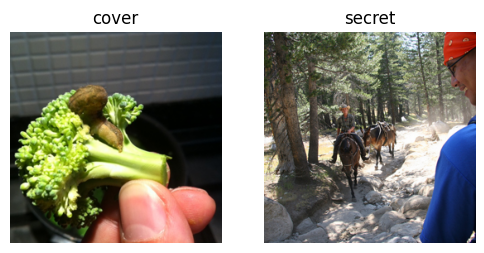

In [8]:
import matplotlib.pyplot as plt

cover, secret = bundle.test[0]
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for axis, image, title in zip(axes, (cover, secret), ("cover", "secret")):
    axis.imshow(image.permute(1, 2, 0).numpy())
    axis.set_title(title)
    axis.axis("off")
plt.show()

## 3. Models and the differentiable codec simulators

The system is the hiding network with frequency-adaptive attention, the reveal
network, and the multi-codec distortion channel `S`.

`S` is **frozen** during steganography training. It is the environment, not a
trained module: if its weights were optimised by the steganography loss, the
joint optimum would be a simulator that distorts nothing, which is exactly the
degenerate solution the compression stage exists to prevent.

The table below is the honest starting point of the whole project: how closely
each simulator reproduces its real encoder before any calibration.

In [9]:
from stegtransx_cr.calibrate import format_gap, measure_gap
from stegtransx_cr.train import StegTransXCR

model_cfg = ModelConfig()
loss_cfg = LossConfig()
system = StegTransXCR(model_cfg).to(DEVICE)

print(f"hiding  {count_parameters(system.hiding) / 1e6:.2f} M parameters")
print(f"reveal  {count_parameters(system.reveal) / 1e6:.2f} M parameters")
print(f"trainable total {sum(p.numel() for p in system.trainable_parameters()) / 1e6:.2f} M")
print()
print("simulator versus real encoders, before calibration:")
print(format_gap(measure_gap(system.simulator, bundle.eval_cache, batch_size=8, device=DEVICE)))

hiding  2.81 M parameters
reveal  0.28 M parameters
trainable total 3.08 M

simulator versus real encoders, before calibration:
codec     q    sim dB   real dB  sim vs real
JPEG     50     31.65     31.62        45.60
JPEG     65     32.46     32.42        43.22
JPEG     80     33.17     33.11        42.93
JPEG     95     37.36     37.20        45.70
WebP     50     31.58     32.28        30.14
WebP     65     31.57     32.18        29.63
WebP     80     33.15     34.28        31.26
WebP     95     36.06     38.06        34.35
HEIF     50     29.52     34.23        29.49
HEIF     65     31.55     36.23        31.17
HEIF     80     35.03     37.79        33.55
HEIF     95     38.23     41.69        36.99
AVIF     50     30.16     30.92        29.19
AVIF     65     32.89     33.91        31.74
AVIF     80     35.29     35.65        33.73
AVIF     95     39.16     40.74        37.33


## 4. Optional: calibrate the simulators against real encoders

The analytical part of each simulator sets the *magnitude* of the distortion. The
learned FiLM, deblocking and CDEF modules are meant to capture the artifact
*shape*, and they start as exact identities, so calibration is what gives them
meaning.

This is a supervised regression of `S(I, k, q)` onto the real encoder output. It
touches simulator parameters only, never the steganography networks. Skip it to
reproduce the paper's purely analytical setup; run it to narrow the
simulator-to-real gap that section 7 reports.

Takes a few minutes. Do it **before** the experiments so all three regimes train
against the same distortion channel.

In [8]:
# RUN_CALIBRATION = True
# SIM_CKPT = os.path.join(PATHS.checkpoints, "simulator_calibrated.pth")

# if RUN_CALIBRATION:
#     from stegtransx_cr.calibrate import calibrate_simulator, load_calibrated_simulator

#     if load_calibrated_simulator(system.simulator, SIM_CKPT, DEVICE):
#         print("reusing the calibrated simulator so A/B/C share the same distortion channel")
#     else:
#         calibrate_simulator(
#             system.simulator,
#             bundle.train_cache,
#             device=DEVICE,
#             steps=600,
#             batch_size=8,
#             checkpoint_path=SIM_CKPT,
#         )
#     print()
#     print("simulator versus real encoders, after calibration:")
#     print(format_gap(measure_gap(system.simulator, bundle.eval_cache, batch_size=8, device=DEVICE)))
# else:
#     print("calibration skipped: using the analytical simulators only")

## 5. Learning sanity check

**Run this before starting the long experiments.** It trains a throwaway copy for
a few hundred steps with the hiding pressure switched off, so the only thing being
optimised is embed-then-extract.

Secret PSNR should climb clearly above where it started. If it stays flat, no
amount of full-length training will fix it, and you have found that out in two
minutes instead of twelve hours.

### Why the hiding loss is ramped rather than fixed

Measured at initialisation, the gradient the hiding loss sends into the hiding
network is about **120 times** the one arriving from the reveal loss through the
reveal network. Optimised jointly from step one, the pair collapses onto the
trivial solution `stego = cover`: cover PSNR looks superb, nothing is embedded,
and the reveal loss never receives a signal.

So `lambda_1` is held at `lambda_hide_start` for `warmup_epochs`, then ramped
linearly to the specified value of 1.0 over `ramp_epochs`. The objective the model
spends most of training under, and converges to, is the one in the specification.

Every epoch also logs `residual`, the mean `|stego - cover|` on the 0-255 scale.
If it falls to zero while secret PSNR is still low, the trainer prints a warning.

In [10]:
from stegtransx_cr.train import learning_sanity_check

check = learning_sanity_check(
    system, train_loader, DEVICE, steps=300, lambda_hide=0.0, loss_cfg=loss_cfg,
)

if check["gain"] <= 1.0:
    raise RuntimeError(
        "Learning sanity check failed: secret PSNR did not rise by more than 1 dB. "
        "Do not start experiments A/B/C."
    )
print("\nOK to proceed to the experiments.")

learning sanity check: 300 steps, lambda_hide = 0.0


/content/drive/MyDrive/stegno/stegtransx_cr/train.py:579: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  f"  step {step:>4} | L_R {float(losses['loss_reveal']):.4f} "


  step    0 | L_R 4.0845 | secret 11.13 dB
  step   50 | L_R 1.8428 | secret 16.06 dB
  step  100 | L_R 1.7014 | secret 16.68 dB
  step  150 | L_R 1.6713 | secret 16.51 dB
  step  200 | L_R 1.0469 | secret 18.65 dB
  step  250 | L_R 1.2972 | secret 18.30 dB
  secret PSNR 11.13 -> 19.48 dB (gain +8.35 dB): learning

OK to proceed to the experiments.


## 6. Experiments

| Regime | Distortion channel during training |
|---|---|
| **A - single** | DiffJPEG at a fixed `q = 80` |
| **B - multi** | codec drawn uniformly from {JPEG, WebP, HEIF, AVIF}, `q ~ U(50, 95)` |
| **C - cascade** | a chain of `N ~ U(1, 3)` compressions, each with its own random codec and quality |

Shared settings: AdamW at `2e-4` with betas `(0.5, 0.999)`, cosine annealing,
mixed precision, batch 32, `lambda = (1.0, 1.0, 0.1)`, at most 500 epochs, early
stopping on validation secret PSNR with patience 9.

Each cell is resumable: rerun it after a disconnect and it picks up from
`last_<name>.pth`. Leave `MAX_HOURS = None` so cascade training is not killed
mid-run; a disconnect still resumes from the last checkpoint. Set a number
only if you want a hard per-experiment cap.

In [11]:
from stegtransx_cr.train import Trainer

# None = run until 500 epochs or early stopping. A 7 h cap would cut experiment C
# short. After a Colab disconnect, rerun the cell; it resumes from last_<name>.pth.
MAX_HOURS = None


def make_experiment(name, mode, **overrides):
    cfg = ExperimentConfig(name=name, mode=mode, batch_size=BATCH_SIZE)
    for key, value in overrides.items():
        setattr(cfg, key, value)
    return cfg


def run_experiment(cfg):
    # Independent run: new hiding/reveal weights, keep the calibrated simulator.
    # Resume still works: Trainer loads last_<name>.pth after this reset.
    system.simulator.freeze()
    system.reset_stego_networks()
    trainer = Trainer(system, cfg, PATHS, DEVICE, loss_cfg=loss_cfg, max_hours=MAX_HOURS)
    trainer.fit(train_loader, val_loader, resume=True)
    return trainer


experiments = {
    "single": make_experiment("single", "single", fixed_codec="JPEG", fixed_quality=80),
    "multi": make_experiment("multi", "multi"),
    "cascade": make_experiment("cascade", "cascade"),
}
for name, cfg in experiments.items():
    print(
        f"{name:<8} epochs {cfg.epochs} | warmup {cfg.warmup_epochs} | "
        f"ramp {cfg.ramp_epochs} | patience {cfg.patience}"
    )

single   epochs 250 | warmup 30 | ramp 120 | patience 9
multi    epochs 250 | warmup 30 | ramp 120 | patience 9
cascade  epochs 250 | warmup 30 | ramp 120 | patience 9


In [12]:
# Experiment A - single codec (DiffJPEG, q = 80)
trainer_a = run_experiment(experiments["single"])

  resumed single from epoch 114

=== Experiment single (mode=single, max 250 epochs, patience 9) ===
    iter    0 | loss 1.8485 | hide 1.4009 | reveal 0.8560 | freq 0.0011
  epoch 115/250 | lam1 0.71 | train 1.7417 | cover 20.18 dB | secret 22.97 dB | residual 18.39/255 | warmup | 32s
    iter    0 | loss 1.6614 | hide 1.2801 | reveal 0.7438 | freq 0.0011
  epoch 116/250 | lam1 0.72 | train 1.7806 | cover 20.37 dB | secret 22.50 dB | residual 18.07/255 | warmup | 21s
    iter    0 | loss 1.8432 | hide 1.3825 | reveal 0.8407 | freq 0.0011
  epoch 117/250 | lam1 0.72 | train 1.7366 | cover 20.29 dB | secret 22.71 dB | residual 18.00/255 | warmup | 21s
    iter    0 | loss 1.8214 | hide 1.3447 | reveal 0.8351 | freq 0.0011
  epoch 118/250 | lam1 0.73 | train 1.7802 | cover 20.31 dB | secret 22.71 dB | residual 18.04/255 | warmup | 21s
    iter    0 | loss 1.8734 | hide 1.3504 | reveal 0.8717 | freq 0.0012
  epoch 119/250 | lam1 0.74 | train 1.7752 | cover 20.56 dB | secret 22.73 dB | res

In [13]:
# Experiment B - multi-codec universal regime
trainer_b = run_experiment(experiments["multi"])


=== Experiment multi (mode=multi, max 250 epochs, patience 9) ===
    iter    0 | loss 3.7606 | hide 1.1401 | reveal 3.7546 | freq 0.0006
  epoch   1/250 | lam1 0.00 | train 2.8090 | cover 8.49 dB | secret 15.91 dB | residual 83.19/255 | warmup | 23s
    iter    0 | loss 2.0778 | hide 5.6400 | reveal 2.0591 | freq 0.0009
  epoch   2/250 | lam1 0.00 | train 1.9653 | cover 8.65 dB | secret 17.24 dB | residual 81.29/255 | warmup | 23s
    iter    0 | loss 1.7900 | hide 5.6638 | reveal 1.7663 | freq 0.0009
  epoch   3/250 | lam1 0.00 | train 1.8329 | cover 8.06 dB | secret 17.95 dB | residual 86.56/255 | warmup | 23s
    iter    0 | loss 1.6218 | hide 5.8303 | reveal 1.6007 | freq 0.0008
  epoch   4/250 | lam1 0.00 | train 1.6476 | cover 8.49 dB | secret 18.26 dB | residual 81.54/255 | warmup | 23s
    iter    0 | loss 1.6683 | hide 5.5949 | reveal 1.6504 | freq 0.0011
  epoch   5/250 | lam1 0.00 | train 1.4656 | cover 8.10 dB | secret 18.96 dB | residual 85.18/255 | warmup | 23s
    iter

In [ ]:
# Experiment C - cascading recompression chains
trainer_c = run_experiment(experiments["cascade"])


=== Experiment cascade (mode=cascade, max 250 epochs, patience 9) ===
    iter    0 | loss 4.1589 | hide 2.8733 | reveal 4.0794 | freq 0.0021
  epoch   1/250 | lam1 0.00 | train 2.8593 | cover 11.02 dB | secret 15.87 dB | residual 62.82/255 | warmup | 25s
    iter    0 | loss 2.1924 | hide 4.7488 | reveal 2.1743 | freq 0.0007
  epoch   2/250 | lam1 0.00 | train 1.8962 | cover 9.68 dB | secret 16.87 dB | residual 71.81/255 | warmup | 24s
    iter    0 | loss 1.8891 | hide 5.0243 | reveal 1.8744 | freq 0.0007
  epoch   3/250 | lam1 0.00 | train 1.7534 | cover 9.69 dB | secret 17.46 dB | residual 71.19/255 | warmup | 25s
    iter    0 | loss 1.7833 | hide 5.0864 | reveal 1.7737 | freq 0.0007
  epoch   4/250 | lam1 0.00 | train 1.6507 | cover 9.03 dB | secret 18.06 dB | residual 75.78/255 | warmup | 24s
    iter    0 | loss 1.6368 | hide 5.5385 | reveal 1.6227 | freq 0.0007
  epoch   5/250 | lam1 0.00 | train 1.6197 | cover 8.60 dB | secret 17.96 dB | residual 80.81/255 | warmup | 24s
   

## 7. Evaluation

Every scenario is measured twice on the 200 unseen test pairs:

- **sim** - through the differentiable simulator, which is the protocol the paper reports
- **real** - through genuine encoder files, which is what happens on an actual platform

Reporting both makes the simulator-to-real gap explicit instead of hiding it. The
gap column is itself a result worth discussing in the report.

Scenarios cover the paper's Table 1 (each codec at `q = 80`), its Table 2
(cascading chains up to `JPEG -> WebP -> HEIF -> AVIF`) and a quality sweep from
`q = 95` down to `q = 50`.

In [ ]:
from stegtransx_cr.eval import export_tables, run_benchmark
from stegtransx_cr.train import load_best

all_rows = []
for name in ("single", "multi", "cascade"):
    checkpoint = os.path.join(PATHS.checkpoints, f"best_{name}.pth")
    if not os.path.exists(checkpoint):
        print(f"skipping {name}: no checkpoint yet")
        continue
    print(f"\n{'=' * 70}\nEvaluating the {name} regime\n{'=' * 70}")
    load_best(system, checkpoint, DEVICE)
    rows = run_benchmark(system, test_loader, DEVICE, experiment=name)
    export_tables(rows, PATHS.tables, name)
    all_rows.extend(rows)

from stegtransx_cr.eval import write_csv

if not all_rows:
    raise RuntimeError("no evaluation rows; train at least one experiment and rerun this cell")
write_csv(all_rows, os.path.join(PATHS.tables, "results_all.csv"))
print(f"\n{len(all_rows)} measurements written to {PATHS.tables}")


Evaluating the single regime

single: single-codec scenarios (sim)
  [sim] None                 cover  20.96 dB | secret  23.23 dB / SSIM 0.7394
  [sim] JPEG                 cover  20.96 dB | secret  22.43 dB / SSIM 0.6545
  [sim] WebP                 cover  20.95 dB | secret  22.93 dB / SSIM 0.7078
  [sim] HEIF                 cover  20.95 dB | secret  22.72 dB / SSIM 0.7104
  [sim] AVIF                 cover  20.95 dB | secret  23.12 dB / SSIM 0.7157

single: cascading scenarios (sim)
  [sim] Single (baseline)    cover  20.96 dB | secret  22.43 dB / SSIM 0.6545
  [sim] Double same          cover  20.96 dB | secret  22.33 dB / SSIM 0.6490
  [sim] Double cross         cover  20.96 dB | secret  22.16 dB / SSIM 0.6313
  [sim] Triple mixed         cover  20.96 dB | secret  22.01 dB / SSIM 0.6289
  [sim] Platform simulate    cover  20.96 dB | secret  21.74 dB / SSIM 0.6165
  [sim] Full chain           cover  20.96 dB | secret  21.67 dB / SSIM 0.6139

single: quality sweep (sim)
  [sim] JP

In [ ]:
import pandas as pd

if not all_rows:
    raise RuntimeError("no evaluation rows; run the evaluation cell first")
frame = pd.DataFrame(all_rows)
summary = frame[frame["group"].isin(["single", "cascade"])].pivot_table(
    index=["experiment", "group", "scenario"],
    columns="engine",
    values="sr_psnr",
)
if {"sim", "real"}.issubset(summary.columns):
    summary["gap"] = summary["sim"] - summary["real"]
summary.round(2)

engine                                 real    sim   gap
experiment group   scenario                             
cascade    cascade Double cross       22.06  22.28  0.22
                   Double same        22.48  22.49  0.01
                   Full chain         21.67  21.72  0.05
                   Platform simulate  22.04  21.92 -0.12
                   Single (baseline)  22.60  22.60  0.01
                   Triple mixed       21.61  22.14  0.53
           single  AVIF               23.21  23.52  0.31
                   HEIF               23.65  23.33 -0.32
                   JPEG               22.60  22.60  0.01
                   None               23.88  23.88  0.00
                   WebP               22.89  23.41  0.52
multi      cascade Double cross       21.78  22.14  0.36
                   Double same        22.27  22.28  0.01
                   Full chain         21.38  21.80  0.43
                   Platform simulate  21.76  21.94  0.18
                   Single (baseline)  22.35  22.36  0.01
                   Triple mixed       21.35  22.03  0.68
           single  AVIF               22.98  23.51  0.53
                   HEIF               23.64  23.56 -0.08
                   JPEG               22.35  22.36  0.01
                   None               23.93  23.93  0.00
                   WebP               22.56  23.44  0.88
single     cascade Double cross       22.02  22.16  0.14
                   Double same        22.32  22.33  0.01
                   Full chain         21.78  21.67 -0.10
                   Platform simulate  21.99  21.74 -0.25
                   Single (baseline)  22.42  22.43  0.01
                   Triple mixed       21.52  22.01  0.48
           single  AVIF               23.26  23.12 -0.14
                   HEIF               23.30  22.72 -0.58
                   JPEG               22.42  22.43  0.01
                   None               23.23  23.23  0.00
                   WebP               22.74  22.93  0.19

In [ ]:
from stegtransx_cr.eval import (
    plot_convergence, plot_experiment_comparison, plot_quality_sweep,
    qualitative_grid, save_sample_images,
)

history_paths = {
    name: os.path.join(PATHS.history, f"history_{name}.csv")
    for name in ("single", "multi", "cascade")
}

for name, path in history_paths.items():
    if os.path.exists(path):
        plot_convergence(path, PATHS.figures, name)
plot_experiment_comparison(history_paths, PATHS.figures)

for name in ("single", "multi", "cascade"):
    checkpoint = os.path.join(PATHS.checkpoints, f"best_{name}.pth")
    if not os.path.exists(checkpoint):
        continue
    load_best(system, checkpoint, DEVICE)
    rows = [r for r in all_rows if r["experiment"] == name]
    plot_quality_sweep(rows, PATHS.figures, name)
    for engine in ("sim", "real"):
        qualitative_grid(
            system, bundle.test, DEVICE, PATHS.figures, name,
            chain=(("JPEG", 80), ("WebP", 80), ("JPEG", 80)) if name == "cascade" else (("JPEG", 80),),
            engine=engine, indices=(0, 1, 2),
        )
    save_sample_images(system, bundle.test, DEVICE, PATHS.samples, name, indices=(0, 1, 2))

print("figures written to", PATHS.figures)

figures written to /content/drive/MyDrive/stegno/runs/figures


In [ ]:
from IPython.display import Image, display

for name in (
    "fig_loss_train_val_all",
    "fig_convergence_all",
    "fig_qualitative_cascade_sim",
    "fig_quality_sweep_cascade",
):
    path = os.path.join(PATHS.figures, f"{name}.png")
    if os.path.exists(path):
        print(name)
        display(Image(filename=path))

## 8. What to carry into the LaTeX report

Everything below is already on Drive under `runs/`.

**Tables** (`runs/tables/`) - each `.tex` file is a self-contained `booktabs`
table, so the paper can `\input{...}` it directly:

- `table_<regime>_single_sim.tex` and `..._real.tex` - the paper's Table 1 layout
- `table_<regime>_cascade_sim.tex` and `..._real.tex` - the paper's Table 2 layout
- `table_<regime>_*_gap.tex` - simulator versus real side by side
- `results_all.csv` - every measurement, for any extra table

**Figures** (`runs/figures/`) - PDF for the paper, PNG for previewing:

- `fig_convergence_<regime>` - the four train loss curves
- `fig_loss_train_val_<regime>` - train vs validation total loss (PDF for the paper)
- `fig_loss_train_val_all` - the same overlay for all three regimes
- `fig_val_psnr_<regime>` - validation PSNR against the 30 dB target
- `fig_convergence_all` - the three regimes overlaid
- `fig_quality_sweep_<regime>` - robustness against the quality factor
- `fig_qualitative_<regime>_<engine>` - cover, secret, stego, residual, compressed, recovered, error

**Raw material**: `runs/history/history_<regime>.csv` (per-epoch losses, PSNR,
SSIM, `lambda_1` and the stego residual) and `runs/checkpoints/best_<regime>.pth`,
so any figure can be regenerated without retraining.

**Do not forget to state in the methods section**: the 500-epoch budget with
patience 9, the codec-free reveal network, the Charbonnier term, the hiding-loss
ramp, and whether simulator calibration was enabled. The real-file tables are the
stronger claim; the simulator tables are the ones comparable with the paper.

In [ ]:
for directory in (PATHS.history, PATHS.checkpoints, PATHS.tables, PATHS.figures, PATHS.samples):
    names = sorted(os.listdir(directory)) if os.path.isdir(directory) else []
    print(f"\n{os.path.relpath(directory, OUTPUT_ROOT)}  ({len(names)} files)")
    for filename in names:
        print("   ", filename)


history  (3 files)
    history_cascade.csv
    history_multi.csv
    history_single.csv

checkpoints  (6 files)
    best_cascade.pth
    best_multi.pth
    best_single.pth
    last_cascade.pth
    last_multi.pth
    last_single.pth

tables  (22 files)
    results_all.csv
    results_cascade.csv
    results_multi.csv
    results_single.csv
    table_cascade_cascade_gap.tex
    table_cascade_cascade_real.tex
    table_cascade_cascade_sim.tex
    table_cascade_single_gap.tex
    table_cascade_single_real.tex
    table_cascade_single_sim.tex
    table_multi_cascade_gap.tex
    table_multi_cascade_real.tex
    table_multi_cascade_sim.tex
    table_multi_single_gap.tex
    table_multi_single_real.tex
    table_multi_single_sim.tex
    table_single_cascade_gap.tex
    table_single_cascade_real.tex
    table_single_cascade_sim.tex
    table_single_single_gap.tex
    table_single_single_real.tex
    table_single_single_sim.tex

figures  (40 files)
    fig_convergence_all.pdf
    fig_convergenc